In [1]:
import pandas as pd
import seaborn as sns
from ipywidgets import interact
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("data.csv")


Basic overview of the dataset

In [3]:


# General info
print(df.shape)
print(df.columns)

# Types and missing values
df.info()

# Statistical summary
df.describe()

# Include categorical if needed
df.describe(include='all')

(536218, 19)
Index(['WELL', 'DATE', 'HOURS', 'WHP', 'WHT', 'C2M', 'C3', 'C4', 'C5P', 'H2O',
       'W_GAS', 'S_GAS', 'LPG_VOL', 'LPG_MASS', 'COND_VOL', 'COND_MASS',
       'WATER', 'prodindex', 'WLP'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 536218 entries, 0 to 536217
Data columns (total 19 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   WELL       536218 non-null  str    
 1   DATE       536218 non-null  str    
 2   HOURS      536160 non-null  float64
 3   WHP        536141 non-null  float64
 4   WHT        536198 non-null  float64
 5   C2M        536218 non-null  float64
 6   C3         536218 non-null  float64
 7   C4         536218 non-null  float64
 8   C5P        536218 non-null  float64
 9   H2O        536218 non-null  float64
 10  W_GAS      536218 non-null  float64
 11  S_GAS      536218 non-null  float64
 12  LPG_VOL    536218 non-null  float64
 13  LPG_MASS   536218 non-null  float64
 14  COND_VOL   536218 

,WELL,DATE,HOURS,WHP,WHT,C2M,C3,C4,C5P,H2O,W_GAS,S_GAS,LPG_VOL,LPG_MASS,COND_VOL,COND_MASS,WATER,prodindex,WLP
count,536218,536218,536160.000000,536141.000000,536198.000000,536218.000000,536218.000000,536218.000000,536218.000000,536218.000000,536218.000000,536218.000000,536218.000000,536218.000000,536218.000000,536218.000000,536218.000000,1.0,362375.000000
unique,100,7494,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,TFT-347,2012-04-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,7365,89,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,21.043460,62.653087,51.835173,0.222277,0.013044,0.005989,0.006989,0.002645,0.248953,0.226975,58.548724,31.312040,42.051204,29.206284,2.122175,0.0,44.784183
std,NaN,NaN,7.438209,30.583846,18.750684,0.170645,0.009906,0.004669,0.006255,0.006820,0.190648,0.174087,44.410405,23.733118,37.662824,26.337536,5.476199,NaN,71.915526
min,NaN,NaN,0.000000,0.000000,-17.777779,-0.055233,-0.003223,-0.001396,-0.001290,-0.004703,-0.065339,-0.056521,-13.991093,-7.505722,-7.602379,-5.234317,-3.777168,0.0,0.000000
25%,NaN,NaN,24.000000,41.799999,50.000000,0.097658,0.005842,0.002668,0.002829,0.000014,0.110568,0.099902,26.232520,14.046252,16.969189,11.703435,0.011335,0.0,38.200000
50%,NaN,NaN,24.000000,63.400002,59.000000,0.194085,0.011437,0.005187,0.005470,0.001014,0.217221,0.198209,51.347950,27.462922,32.860638,22.715706,0.813275,0.0,43.200000
75%,NaN,NaN,24.000000,87.000000,63.000000,0.312888,0.018397,0.008380,0.009356,0.002616,0.348991,0.319650,82.614868,44.177898,56.386627,39.092819,2.098209,0.0,59.600000


Convert DATE column

In [4]:
df['DATE'] = pd.to_datetime(df['DATE'])

In [5]:
df['ACTIVE'] = df['HOURS'].apply(lambda x: 1 if pd.notna(x) and x > 0 else 0)

In [6]:
# Number of unique wells
print(df['WELL'].nunique())

# Number of dates
print(df['DATE'].nunique())

# Count entries per well
well_counts = df['WELL'].value_counts()

print(well_counts.head())

100
7494
WELL
TFT-347     7365
TFT-335Z    7360
TFT-355     7360
TFT-333Z    7354
TFT-358     7353
Name: count, dtype: int64


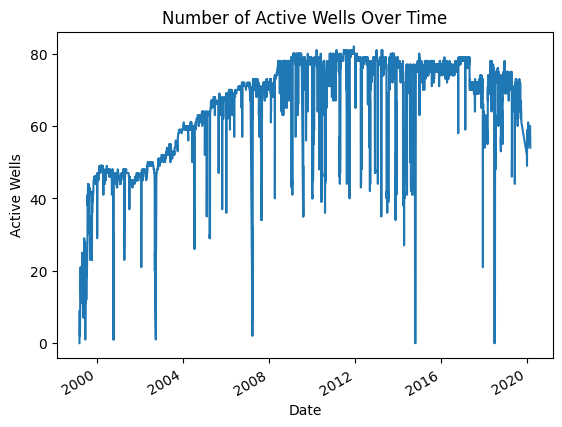

In [7]:
import matplotlib.pyplot as plt

activity_per_day = df.groupby('DATE')['ACTIVE'].sum()

plt.figure()
activity_per_day.plot()
plt.title("Number of Active Wells Over Time")
plt.xlabel("Date")
plt.ylabel("Active Wells")
plt.show()

In [10]:
missing_ratio = pivot.isna().mean()

print(missing_ratio.sort_values(ascending=False).head(20))

WELL
TFT-112      0.999867
TFT-301      0.999867
TFT-321      0.999867
TFT-312      0.999867
TFT-322      0.999867
TFW-1        0.999867
TFY-29       0.999867
TFY-18       0.999867
TFTW-377Z    0.999867
TML-1        0.983587
TFY-30       0.836803
TFT-323      0.606085
TFT-303      0.598212
TFT-388      0.584067
TFT-383      0.557379
TFTW-397     0.529490
TFTW-707     0.512677
TFTW-398     0.498265
TFT-305      0.488924
TFT-704      0.478783
dtype: float64


In [12]:
df.isnull().sum()

WELL              0
DATE              0
HOURS            58
WHP              77
WHT              20
C2M               0
C3                0
C4                0
C5P               0
H2O               0
W_GAS             0
S_GAS             0
LPG_VOL           0
LPG_MASS          0
COND_VOL          0
COND_MASS         0
WATER             0
prodindex    536217
WLP          173843
ACTIVE            0
dtype: int64